In [1]:
%load_ext autoreload
%autoreload 2


import hbsir
from src.prepare import *
from src.eda import DescriptiveAnalyzer as da

pd.set_option('display.max_columns', 120)

In [2]:
YEAR = 1402
years = list(range(1396, 1403))

tables_to_use = [
    "Weight",
    "household_information",
    "house_specifications",
    "Number_of_Members",
    "members_properties",
    "Total_Outlays",
    "Total_Income",
    "home",
    "furniture",
    "Imputed_Rent"
]


In [3]:
house_spec_inspector = TableInspector(table_name="house_specifications", years="1396-1403")
house_spec_inspector.load_table()

target_df = house_spec_inspector.df[["ID", "Year", "Tenure"]].copy()

Table 'house_specifications' loaded with 269609 rows and 49 columns.



In [4]:
target_df.head()

,ID,Year,Tenure
0,20007017925,1396,Owned_Estate_Land
1,20003012637,1396,Owned_Estate_Land
2,20013023737,1396,Owned_Estate_Land
3,20003012640,1396,Owned_Estate_Land
4,20013023733,1396,Owned_Estate_Land


In [83]:
household_info = hbsir.load_table("household_information", years = years, form="cleaned").sort_values(by=["ID", "Season_Number"])

household_info.head()

,ID,Month,Season_Number,Weight,Household_Type,Main_Household,Alternative_Household
56572,10001000102,11.0,4,1176.00000,Normal,True,False
56573,10001000105,11.0,4,1176.00000,Normal,True,False
56574,10001000108,11.0,4,1176.00000,Normal,True,False
110700,10001000108,11.0,4,1199.12892,Normal,True,False
56575,10001000111,11.0,4,1176.00000,Normal,True,False


In [7]:
house_spec = prepare_house_specifications()

house_spec.head()

Table 'house_specifications' loaded with 269609 rows and 49 columns.

Dropped columns: ['Other_Dwelling_Types', 'No_Appliances', 'Tenure']

--- ID ---
Min: 10001000102, Max: 23006709847

--- Number_of_Rooms ---
Min: 0, Max: 12

--- House_Area ---
Min: 0, Max: 800

--- Structure_Type ---
Unique values (3): ['Other', 'Metal', 'Reinforced_Concrete']
Categories (3, object): ['Metal', 'Reinforced_Concrete', 'Other']

--- Structure_Main_Materials ---
Unique values (9): ['Brick_and_Wood_or_Stone_and_Wood' 'Adobe_and_Wood'
 'Brick_and_Iron_or_Stone_and_Iron' 'Adobe_and_Clay'
 'All_Brick_or_Stone_and_Brick' 'Cement_Block' 'Other' 'All_Wood' '8']

--- Car ---
Min: False, Max: True

--- Motorcycle ---
Min: False, Max: True

--- Bicycle ---
Min: False, Max: True

--- Radio ---
Min: False, Max: True

--- Cassette ---
Min: False, Max: True

--- Black_and_White_TV ---
Min: False, Max: True

--- Color_TV ---
Min: False, Max: True

--- VCR ---
Min: False, Max: True

--- PC ---
Min: False, Max: True

--

,ID,Number_of_Rooms,House_Area,Car,Motorcycle,Bicycle,Radio,Cassette,Black_and_White_TV,Color_TV,VCR,PC,Cellphone,Freezer,Refrigerator,Freezer_Refrigerator,Oven,Vacuum_Cleaner,Washing_Machine,Sewing_Machine,Fan,Portable_Evaporative_AC,Portable_Split_AC,Dishwasher,Microwave_Oven,Pipe_Water,Electricity,Natural_Gas,Phone,Internet,Bathroom,Kitchen,Evaporative_AC,Central_AC,Central_Heating,Water_Heater,Split_AC,Sewerage,Year,Elevator,Structure_Type_Reinforced_Concrete,Structure_Type_Other,Structure_Main_Materials_Adobe_and_Clay,Structure_Main_Materials_Adobe_and_Wood,Structure_Main_Materials_All_Brick_or_Stone_and_Brick,Structure_Main_Materials_All_Wood,Structure_Main_Materials_Brick_and_Iron_or_Stone_and_Iron,Structure_Main_Materials_Brick_and_Wood_or_Stone_and_Wood,Structure_Main_Materials_Cement_Block,Structure_Main_Materials_Other,Cooking_Fuel_4,Cooking_Fuel_Electricity,Cooking_Fuel_Gasoline,Cooking_Fuel_Karosine,Cooking_Fuel_Liquid_Gas,Cooking_Fuel_None,Cooking_Fuel_Other_Fuel,Cooking_Fuel_Piped_Gas,Cooking_Fuel_Wood_and_Charcoal,Heating_Fuel_Electricity,Heating_Fuel_Gasoline,Heating_Fuel_Karosine,Heating_Fuel_Liquid_Gas,Heating_Fuel_None,Heating_Fuel_Other_Fuel,Heating_Fuel_Piped_Gas,Heating_Fuel_Wood_and_Charcoal,Hotwater_Fuel_Gasoline,Hotwater_Fuel_Liquid_Gas,Hotwater_Fuel_Piped_Gas,Hotwater_Fuel_Electricity,Hotwater_Fuel_Wood_and_Charcoal,Hotwater_Fuel_Animal_Fuel,Hotwater_Fuel_Other_Fuel,Hotwater_Fuel_None,Dwelling_Type_Non_Apartment_Unit,Dwelling_Type_Other
0,20007017925,5,100,True,True,False,False,False,False,True,True,False,True,True,True,False,True,True,False,True,False,False,False,False,False,True,True,True,False,False,True,True,True,False,False,False,False,False,1396,<NA>,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
1,20003012637,4,60,False,False,False,True,False,False,True,True,False,True,False,False,True,True,True,False,False,True,False,False,False,False,True,True,True,False,False,True,True,True,False,False,False,False,False,1396,<NA>,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
2,20013023737,3,90,True,True,False,False,False,False,True,False,False,True,True,True,False,True,True,False,True,True,False,False,False,False,True,True,True,True,False,True,True,True,False,False,False,False,False,1396,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
3,20003012640,4,85,False,True,False,False,False,False,True,False,False,True,False,False,True,True,True,True,False,True,False,False,False,False,True,True,True,False,True,True,True,False,False,False,False,False,False,1396,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False
4,20013023733,3,80,True,True,False,False,False,False,True,True,True,True,True,True,False,True,True,True,True,True,False,False,False,True,True,True,True,True,True,True,True,True,False,False,False,False,False,1396,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False


In [62]:
house_spec.columns

Index(['ID', 'Number_of_Rooms', 'House_Area', 'Car', 'Motorcycle', 'Bicycle',
       'Radio', 'Cassette', 'Black_and_White_TV', 'Color_TV', 'VCR', 'PC',
       'Cellphone', 'Freezer', 'Refrigerator', 'Freezer_Refrigerator', 'Oven',
       'Vacuum_Cleaner', 'Washing_Machine', 'Sewing_Machine', 'Fan',
       'Portable_Evaporative_AC', 'Portable_Split_AC', 'Dishwasher',
       'Microwave_Oven', 'Pipe_Water', 'Electricity', 'Natural_Gas', 'Phone',
       'Internet', 'Bathroom', 'Kitchen', 'Evaporative_AC', 'Central_AC',
       'Central_Heating', 'Water_Heater', 'Split_AC', 'Sewerage', 'Year',
       'Elevator', 'Structure_Type_Reinforced_Concrete',
       'Structure_Type_Other', 'Structure_Main_Materials_Adobe_and_Clay',
       'Structure_Main_Materials_Adobe_and_Wood',
       'Structure_Main_Materials_All_Brick_or_Stone_and_Brick',
       'Structure_Main_Materials_All_Wood',
       'Structure_Main_Materials_Brick_and_Iron_or_Stone_and_Iron',
       'Structure_Main_Materials_Brick_and_Wood

In [8]:
members_properties = prepare_members_properties()

members_properties.head()

Table 'members_properties' loaded with 910964 rows and 11 columns.


--- Year ---
Min: 1396, Max: 1402

--- ID ---
Min: 10001000102, Max: 23006709847

--- Member_Number ---
Min: 1, Max: 18

--- Relationship ---
Unique values (9): ['Head', 'Spouse', 'Child', 'Child_in_Law', 'Grand_Child', 'Parent', 'Sibling', 'Non_Family', 'Other_Family']
Categories (9, object): ['Head', 'Spouse', 'Child', 'Child_in_Law', ..., 'Parent', 'Sibling', 'Other_Family', 'Non_Family']

--- Sex ---
Unique values (2): ['Male', 'Female']
Categories (2, object): ['Male', 'Female']

--- Age ---
Min: 0, Max: 99

--- Is_Literate ---
Min: False, Max: True

--- Is_Student ---
Min: False, Max: True

--- Education_Level ---
Unique values (9): ['Primary', 'Unofficial', 'Lower_Secondary', 'Bachelors', 'Pre_University', 'Higher_Secondary', 'Short_Cycle_Tertiary', 'Masters', 'Doctoral']
Categories (9, object): ['Primary', 'Lower_Secondary', 'Higher_Secondary', 'Pre_University', ..., 'Bachelors', 'Masters', 'Doctoral', 'Unoffi

,ID,Year,Literate_Count,Student_Count,Mean_Age,Max_Age,Min_Age,Employed,Unemployed,Income_without_Work,Student,Housekeeper,Other,Married,Widowed,Divorced,Bachelor,Male,Female,Head_Education_Primary,Head_Education_Lower_Secondary,Head_Education_Higher_Secondary,Head_Education_Pre_University,Head_Education_Short_Cycle_Tertiary,Head_Education_Bachelors,Head_Education_Masters,Head_Education_Doctoral,Head_Education_Unofficial
0,10001000126,1396,1,0,61.0,61,61,0,0,1,0,0,0,0,1,0,0,0,1,True,False,False,False,False,False,False,False,False
1,10001000127,1396,4,2,27.75,42,13,1,0,1,2,0,0,2,0,0,2,2,2,True,False,False,False,False,False,False,False,False
2,10001000132,1396,1,0,72.0,77,67,0,0,1,0,1,0,2,0,0,0,1,1,False,False,False,False,False,False,False,False,False
3,10001000135,1396,1,0,50.0,70,30,1,0,1,0,0,0,0,1,0,1,1,1,False,False,False,False,False,False,False,False,False
4,10001000138,1396,2,1,35.5,53,18,0,0,1,1,0,0,0,1,0,1,0,2,False,False,False,False,True,False,False,False,False


In [87]:

# hi1 = hbsir.load_table('household_information', years="1403", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi2 = hbsir.load_table('household_information', years="1402", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi3 = hbsir.load_table('household_information', years="1401", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi4 = hbsir.load_table('household_information', years="1400", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi5 = hbsir.load_table('household_information', years="1399", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi6 = hbsir.load_table('household_information', years="1398", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi7 = hbsir.load_table('household_information', years="1397", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]
hi8 = hbsir.load_table('household_information', years="1396", form="cleaned").sort_values(by=["ID", "Season_Number"])[["ID", "Weight"]]

# hi1["Year"] = 1403
hi2["Year"] = 1402
hi3["Year"] = 1401
hi4["Year"] = 1400
hi5["Year"] = 1399
hi6["Year"] = 1398
hi7["Year"] = 1397
hi8["Year"] = 1396


weight = pd.concat([ hi2, hi3, hi4, hi5, hi6, hi7, hi8], ignore_index=True)

weight.head()


,ID,Weight,Year
0,10001000132,1290.131402,1402
1,10001000135,1290.131402,1402
2,10001000141,1290.131402,1402
3,10001000142,1290.131402,1402
4,10001000144,1290.131402,1402


In [9]:
number_of_members = hbsir.load_table("Number_of_Members", years=years)

number_of_members.head()

,Year,ID,Members,Adults,Childs
0,1396,10001000126,1,1,0
1,1396,10001000127,4,3,1
2,1396,10001000132,2,2,0
3,1396,10001000135,2,2,0
4,1396,10001000138,2,2,0


In [10]:
outlays = hbsir.load_table("Total_Outlay", years=years)

outlays.head()

,Year,ID,Gross_Expenditure,Net_Expenditure
0,1396,10001000126,186574000.0,0.0
1,1396,10001000127,168310388.0,0.0
2,1396,10001000132,164784000.0,0.0
3,1396,10001000135,150418000.0,0.0
4,1396,10001000138,233027800.0,0.0


In [11]:
total_income = hbsir.load_table("Total_Income", years=years)

total_income.head()

,Year,ID,Income
0,1396,10001000126,219460000.0
1,1396,10001000127,366654388.0
2,1396,10001000132,275920000.0
3,1396,10001000135,264920000.0
4,1396,10001000138,259832000.0


In [12]:
home = prepare_home()

home.head()

Table 'home' loaded with 1092665 rows and 8 columns.


--- Year ---
Min: 1396, Max: 1402

--- ID ---
Min: 10001000102, Max: 23006709847

--- Table_Name ---
Unique values (1): ['home']

--- Commodity_Code ---
Min: 41111, Max: 45414

--- Provision_Method ---
Unique values (8): ['Purchase' 'Donation' 'Home_Production' 'Instead_of_Public_Service'
 'Instead_of_Private_Service' 'Non_Agricultural_Work' 'Agricultural_Work'
 'Instead_of_Cooperative_Service']

--- Duration ---
Min: 30, Max: 30

--- Expenditure ---
Min: 2000.0, Max: 2500000000.0

--- Security_Deposit ---
Min: 1.0, Max: 13000000000.0


,ID,Year,Home_Expenditure
0,10001000126,1396,5950000.0
1,10001000127,1396,5250000.0
2,10001000132,1396,5257000.0
3,10001000135,1396,4585000.0
4,10001000138,1396,4320000.0


In [13]:
furniture = prepare_furniture()

furniture.head()

Table 'furniture' loaded with 1301461 rows and 7 columns.


--- Year ---
Min: 1396, Max: 1402

--- ID ---
Min: 10001000102, Max: 23006709847

--- Table_Name ---
Unique values (1): ['furniture']

--- Commodity_Code ---
Min: 52111, Max: 56215

--- Provision_Method ---
Unique values (8): ['Purchase' 'Non_Agricultural_Work' 'Donation' 'Home_Production'
 'Instead_of_Private_Service' 'Instead_of_Public_Service'
 'Agricultural_Work' 'Instead_of_Cooperative_Service']

--- Duration ---
Min: 30, Max: 30

--- Expenditure ---
Min: 1000.0, Max: 500000000.0


,ID,Year,Furniture_Expenditure
0,10001000126,1396,180000.0
1,10001000127,1396,250000.0
2,10001000132,1396,275000.0
3,10001000135,1396,240000.0
4,10001000138,1396,605000.0


In [14]:
imputed_rent = prepare_imputed_rent()

imputed_rent.head()

Table 'Imputed_Rent' loaded with 238253 rows and 4 columns.


--- Year ---
Min: 1396, Max: 1402

--- ID ---
Min: 10001000102, Max: 23006709847

--- Income_Type ---
Unique values (2): ['NonCash_ImputedRent_Ownership', 'NonCash_ImputedRent_Mortgage']
Categories (2, object): ['NonCash_ImputedRent_Ownership', 'NonCash_ImputedRent_Mortgage']

--- Income ---
Min: 356400.0, Max: 30000001024.0


D:\SUT\cources\regression\project2\project2\src\prepare.py:153: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = df.pivot_table(


,ID,Year,Imputed_Rent_Ownership,Imputed_Rent_Mortgage
0,10001000102,1396,0.0,0.0
1,10001000102,1397,114000000.0,0.0
2,10001000102,1398,0.0,0.0
3,10001000102,1399,0.0,0.0
4,10001000102,1400,0.0,0.0


In [88]:
dfs = [
    house_spec,
    # household_info,
    members_properties,
    number_of_members,
    outlays,
    total_income,
    home,
    furniture,
    # imputed_rent
]

df = merge_dataframes(dfs)

df.head()

,ID,Number_of_Rooms,House_Area,Car,Motorcycle,Bicycle,Radio,Cassette,Black_and_White_TV,Color_TV,VCR,PC,Cellphone,Freezer,Refrigerator,Freezer_Refrigerator,Oven,Vacuum_Cleaner,Washing_Machine,Sewing_Machine,Fan,Portable_Evaporative_AC,Portable_Split_AC,Dishwasher,Microwave_Oven,Pipe_Water,Electricity,Natural_Gas,Phone,Internet,Bathroom,Kitchen,Evaporative_AC,Central_AC,Central_Heating,Water_Heater,Split_AC,Sewerage,Year,Elevator,Structure_Type_Reinforced_Concrete,Structure_Type_Other,Structure_Main_Materials_Adobe_and_Clay,Structure_Main_Materials_Adobe_and_Wood,Structure_Main_Materials_All_Brick_or_Stone_and_Brick,Structure_Main_Materials_All_Wood,Structure_Main_Materials_Brick_and_Iron_or_Stone_and_Iron,Structure_Main_Materials_Brick_and_Wood_or_Stone_and_Wood,Structure_Main_Materials_Cement_Block,Structure_Main_Materials_Other,Cooking_Fuel_4,Cooking_Fuel_Electricity,Cooking_Fuel_Gasoline,Cooking_Fuel_Karosine,Cooking_Fuel_Liquid_Gas,Cooking_Fuel_None,Cooking_Fuel_Other_Fuel,Cooking_Fuel_Piped_Gas,Cooking_Fuel_Wood_and_Charcoal,Heating_Fuel_Electricity,Heating_Fuel_Gasoline,Heating_Fuel_Karosine,Heating_Fuel_Liquid_Gas,Heating_Fuel_None,Heating_Fuel_Other_Fuel,Heating_Fuel_Piped_Gas,Heating_Fuel_Wood_and_Charcoal,Hotwater_Fuel_Gasoline,Hotwater_Fuel_Liquid_Gas,Hotwater_Fuel_Piped_Gas,Hotwater_Fuel_Electricity,Hotwater_Fuel_Wood_and_Charcoal,Hotwater_Fuel_Animal_Fuel,Hotwater_Fuel_Other_Fuel,Hotwater_Fuel_None,Dwelling_Type_Non_Apartment_Unit,Dwelling_Type_Other,Literate_Count,Student_Count,Mean_Age,Max_Age,Min_Age,Employed,Unemployed,Income_without_Work,Student,Housekeeper,Other,Married,Widowed,Divorced,Bachelor,Male,Female,Head_Education_Primary,Head_Education_Lower_Secondary,Head_Education_Higher_Secondary,Head_Education_Pre_University,Head_Education_Short_Cycle_Tertiary,Head_Education_Bachelors,Head_Education_Masters,Head_Education_Doctoral,Head_Education_Unofficial,Members,Adults,Childs,Gross_Expenditure,Net_Expenditure,Income,Home_Expenditure,Furniture_Expenditure,Weight
0,10001000102,4,170,True,False,False,False,False,False,True,False,False,True,False,False,True,True,True,True,True,False,False,False,False,False,True,True,True,True,True,True,True,True,False,False,False,False,False,1397,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,4,0,41.0,60,25,0.0,2.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,2.0,3.0,1.0,True,False,False,False,False,False,False,False,False,4,4,0,317462000.0,0.0,311840000.0,10135000.0,790000.0,1176.00000
1,10001000105,4,100,False,False,False,False,False,False,True,False,False,True,False,False,True,True,True,True,True,False,False,False,False,True,True,True,True,True,False,True,True,True,False,False,False,False,False,1397,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,0,0,72.0,72,72,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,False,False,False,False,False,False,False,False,False,1,1,0,313468000.0,0.0,259460000.0,9028000.0,490000.0,1176.00000
2,10001000108,4,130,True,False,False,False,False,False,True,False,False,True,False,False,True,True,True,True,True,True,False,False,False,False,True,True,True,True,False,True,True,True,False,False,False,False,False,1397,<NA>,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,3,0,58.0,77,32,0.0,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,False,False,False,False,False,True,False,False,False,3,3,0,347480000.0,0.0,662380000.0,9155000.0,1480000.0,1176.00000
3,10001000108,4,135,False,False,False,False,False,False,True,False,False,True,True,True,False,True,True,True,True,False,

In [16]:
df.columns.values

array(['ID', 'Number_of_Rooms', 'House_Area', 'Car', 'Motorcycle',
       'Bicycle', 'Radio', 'Cassette', 'Black_and_White_TV', 'Color_TV',
       'VCR', 'PC', 'Cellphone', 'Freezer', 'Refrigerator',
       'Freezer_Refrigerator', 'Oven', 'Vacuum_Cleaner',
       'Washing_Machine', 'Sewing_Machine', 'Fan',
       'Portable_Evaporative_AC', 'Portable_Split_AC', 'Dishwasher',
       'Microwave_Oven', 'Pipe_Water', 'Electricity', 'Natural_Gas',
       'Phone', 'Internet', 'Bathroom', 'Kitchen', 'Evaporative_AC',
       'Central_AC', 'Central_Heating', 'Water_Heater', 'Split_AC',
       'Sewerage', 'Year', 'Elevator',
       'Structure_Type_Reinforced_Concrete', 'Structure_Type_Other',
       'Structure_Main_Materials_Adobe_and_Clay',
       'Structure_Main_Materials_Adobe_and_Wood',
       'Structure_Main_Materials_All_Brick_or_Stone_and_Brick',
       'Structure_Main_Materials_All_Wood',
       'Structure_Main_Materials_Brick_and_Iron_or_Stone_and_Iron',
       'Structure_Main_Materials_

In [89]:
df = add_composite_features(df)

In [90]:
df = add_geographical_features(df)

In [19]:
df = add_quintile_decile(df)

KeyError: "['Season'] not in index"

In [20]:
df.columns.values

array(['ID', 'Number_of_Rooms', 'House_Area', 'Car', 'Motorcycle',
       'Bicycle', 'Radio', 'Cassette', 'Black_and_White_TV', 'Color_TV',
       'VCR', 'PC', 'Cellphone', 'Freezer', 'Refrigerator',
       'Freezer_Refrigerator', 'Oven', 'Vacuum_Cleaner',
       'Washing_Machine', 'Sewing_Machine', 'Fan',
       'Portable_Evaporative_AC', 'Portable_Split_AC', 'Dishwasher',
       'Microwave_Oven', 'Pipe_Water', 'Electricity', 'Natural_Gas',
       'Phone', 'Internet', 'Bathroom', 'Kitchen', 'Evaporative_AC',
       'Central_AC', 'Central_Heating', 'Water_Heater', 'Split_AC',
       'Sewerage', 'Year', 'Elevator',
       'Structure_Type_Reinforced_Concrete', 'Structure_Type_Other',
       'Structure_Main_Materials_Adobe_and_Clay',
       'Structure_Main_Materials_Adobe_and_Wood',
       'Structure_Main_Materials_All_Brick_or_Stone_and_Brick',
       'Structure_Main_Materials_All_Wood',
       'Structure_Main_Materials_Brick_and_Iron_or_Stone_and_Iron',
       'Structure_Main_Materials_

In [24]:
target_df.to_parquet("target.parquet", index=False)
df.to_parquet("features.parquet", index=False)

In [21]:
print(df['Year'].dtype)
print(df['Year'].isna().sum())


int64
0


In [ ]:
df = hbsir.calculate.add_quantile(
    table=df,
    on_column="Income",
    bins=5,
    quantile_column_name="Income_Quintile",
    weight_column="Weight",
    annual=True
)

df = hbsir.calculate.add_decile(
    table=df,
    on_column="Income",
    quantile_column_name="Income_Decile",
    weight_column="Weight",
    annual=True
)

In [34]:
df[["ID", "Year", "Income_Quintile", "Income_Decile"]].head()

KeyError: "['Income_Quintile', 'Income_Decile'] not in index"

In [22]:
analyzer = da(df, target_df, target_col="Tenure")

,Count,Percentage
Tenure,,
Owned_Estate_Land,208291,78.12
Rent,24942,9.35
Free,19730,7.40
Mortgage,9443,3.54
Service,2421,0.91
Owned_Estate,1435,0.54
Other,358,0.13


D:\SUT\cources\regression\project2\project2\src\eda.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


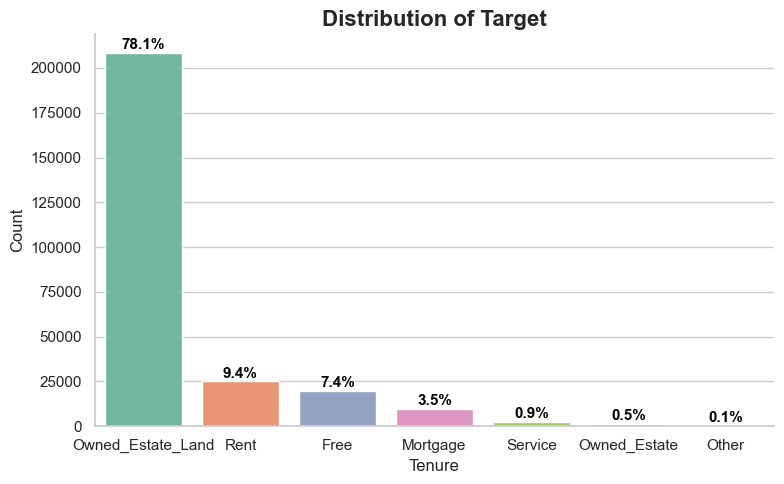

,Count,Percentage
Tenure,,
Owned_Estate_Land,208291,78.12
Rent,24942,9.35
Free,19730,7.40
Mortgage,9443,3.54
Service,2421,0.91
Owned_Estate,1435,0.54
Other,358,0.13


In [23]:
analyzer.target_distribution(plot_type='bar')

In [30]:
analyzer.target_by_category('Region_Type')

KeyError: 'Region_Type'

In [35]:
num_features = ['Income', 'Wealth', 'House_Area']

In [36]:
analyzer.numeric_summary_by_target(num_features)
analyzer.numeric_boxplot_by_target(num_features)

D:\SUT\cources\regression\project2\project2\src\eda.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = self.df.groupby(self.target_col)[num_features].agg(['mean', 'median', 'std'])


KeyError: "Columns not found: 'Wealth'"

In [37]:
analyzer.correlation_heatmap(num_features)

KeyError: "['Wealth'] not in index"

In [38]:
analyzer.missing_values()

Missing values:
 Number_of_Rooms             428535
House_Area                  428539
Car                         428530
Motorcycle                  428530
Bicycle                     428530
                             ...  
Imputed_Rent_Mortgage        92337
Density                     469393
Income_Expenditure_Ratio    392472
Area_per_Capita             431519
Tenure                      431519
Length: 115, dtype: int64


Number_of_Rooms             428535
House_Area                  428539
Car                         428530
Motorcycle                  428530
Bicycle                     428530
                             ...  
Imputed_Rent_Mortgage        92337
Density                     469393
Income_Expenditure_Ratio    392472
Area_per_Capita             431519
Tenure                      431519
Length: 115, dtype: int64

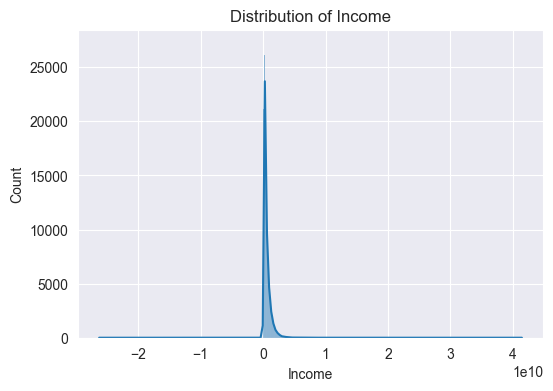

KeyError: 'Wealth'

<Figure size 600x400 with 0 Axes>

In [42]:
analyzer.numeric_distribution(num_features)

In [41]:
an = dap(features_df=df, target_df=target_df,
         id_col="ID", year_col="Year", target_col="Tenure")

(621217, 118)

In [ ]:
stats = an.summary_stats()
display(stats.head())

In [ ]:
report = an.quick_report()
display(report['chi2'])
display(report['anova'])
display(report['mutual_info'])

In [ ]:
corr_figs = an.correlation_heatmaps(save_prefix="corr_plot")
corr_figs['overall'].show()

In [ ]:
vfigs = an.violin_plots(numeric_features=["Income", "Net_Expenditure"], save_prefix="violin")
vfigs["Income"].show()

In [ ]:
dist_figs = an.distribution_by_target(numeric_features=["Income"], bins=30)
dist_figs["Income"].show()

In [ ]:
mi = an.mutual_info_ranking()
display(mi.head(20))

In [ ]:
chi2_df = an.chi2_tests_categorical()
display(chi2_df.sort_values("p_value").head(30))

In [25]:
target_df.shape

(269609, 3)

In [26]:
df.shape

(1126977, 118)

In [27]:
house_spec.shape

(269609, 77)

In [99]:
new_dfs = [
    house_spec,
    # household_info,
    members_properties,
    number_of_members,
    outlays,
    total_income,
    home,
    furniture,
    # imputed_rent
]

In [28]:
members_properties.shape

(266629, 28)

In [29]:
number_of_members.shape

(266629, 5)

In [30]:
outlays.shape

(266629, 4)

In [31]:
total_income.shape

(266627, 3)

In [32]:
home.shape

(266629, 3)

In [33]:
furniture.shape

(248240, 3)

In [34]:
imputed_rent.shape

(1104446, 4)

In [35]:
imputed_rent.head(20)

,ID,Year,Imputed_Rent_Ownership,Imputed_Rent_Mortgage
0,10001000102,1396,0.0,0.0
1,10001000102,1397,114000000.0,0.0
2,10001000102,1398,0.0,0.0
3,10001000102,1399,0.0,0.0
4,10001000102,1400,0.0,0.0
5,10001000102,1401,0.0,0.0
6,10001000102,1402,0.0,0.0
7,10001000105,1396,0.0,0.0
8,10001000105,1397,102000000.0,0.0
9,10001000105,1398,0.0,0.0


In [48]:
# check duplicates based on year and id
dupes = number_of_members[number_of_members.duplicated(subset=["Year", "ID"], keep=False)]

print(dupes.sort_values(by=["Year", "ID"]))



Empty DataFrame
Columns: [Year, ID, Members, Adults, Childs]
Index: []


In [46]:
h = hbsir.load_table("members_properties", years=years)

In [47]:
dupes = h[h.duplicated(subset=["Year", "ID"], keep=False)]

print(dupes.sort_values(by=["Year", "ID"]))

        Year           ID  Member_Number Relationship     Sex  Age  \
68862   1396  10001000127              1         Head    Male   40   
68863   1396  10001000127              2       Spouse  Female   42   
68864   1396  10001000127              3        Child    Male   16   
68865   1396  10001000127              4        Child  Female   13   
68847   1396  10001000132              1         Head    Male   77   
...      ...          ...            ...          ...     ...  ...   
808686  1402  23006709844              2       Spouse  Female   28   
808687  1402  23006709844              3        Child  Female    4   
808765  1402  23006709847              1         Head    Male   52   
808766  1402  23006709847              2       Spouse  Female   48   
808767  1402  23006709847              3        Child    Male    9   

        Is_Literate  Is_Student   Education_Level Marital_Status  \
68862          True       False           Primary        Married   
68863          True    

In [44]:
h.shape

(269609, 49)

In [108]:
merged_df = merge_dataframes(new_dfs)

In [109]:
merged_df.shape

(269609, 111)

In [110]:
target_df.shape

(269609, 3)

In [111]:
merged_df = add_composite_features(merged_df)

In [112]:
merged_df = add_geographical_features(merged_df)

In [104]:
merged_df = standardize_numeric(df=merged_df)

Standardized columns: ['Number_of_Rooms', 'House_Area', 'Literate_Count', 'Student_Count', 'Mean_Age', 'Max_Age', 'Min_Age', 'Employed', 'Unemployed', 'Income_without_Work', 'Student', 'Housekeeper', 'Other', 'Married', 'Widowed', 'Divorced', 'Bachelor', 'Male', 'Female', 'Members', 'Adults', 'Childs', 'Gross_Expenditure', 'Net_Expenditure', 'Income', 'Home_Expenditure', 'Furniture_Expenditure', 'Density', 'Income_Expenditure_Ratio', 'Area_per_Capita']


In [113]:
weighted_df = pd.merge(merged_df, weight, on=["Year", "ID"], how="left")

weighted_df.shape

(269609, 117)

In [114]:
weighted_df.to_parquet("weighted_features.parquet", index=False)

In [58]:
non_numeric_cols = merged_df.select_dtypes(include=["object", "category"]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)


Non-numeric columns: ['Head_Education_Primary', 'Head_Education_Lower_Secondary', 'Head_Education_Higher_Secondary', 'Head_Education_Pre_University', 'Head_Education_Short_Cycle_Tertiary', 'Head_Education_Bachelors', 'Head_Education_Masters', 'Head_Education_Doctoral', 'Head_Education_Unofficial', 'Urban_Rural', 'Province']


In [60]:
merged_df = pd.get_dummies(merged_df, columns=non_numeric_cols, drop_first=True)

In [61]:
merged_df.to_parquet("features2.parquet", index=False)